In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# 1. CARGA Y PREPARACIÓN
df = pd.read_csv(r'C:\Users\braya\Documents\TFM_UCM_Enagas\tfm_enagas\data\processed\df_etiquetado_erm400.csv', index_col='datetime', parse_dates=True)
df.head(3)

,presion_in_A,presion_in_B,temperatura_in_A,temperatura_in_B,caudal_bruto_A,caudal_bruto_B,caudal_nominal_A,caudal_nominal_B,caudal_min_diario_A,caudal_min_diario_B,caudal_max_diario_A,caudal_max_diario_B,is_anomaly_sap,tipo_fallo_sap_detalle,anomaly_IF,target_sap_IF,delta_presion_temp,is_scada_anomaly,tipo_fallo_scada,inestabilidad_z
datetime,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,16.784145,16.792011,11.613059,4.581303,0.0,49.199109,0.0,841.179544,0,0,64135.745844,13746.320905,0,Normal,0,0,0.000000,0,Normal / Sin Fallo,1.133893
2023-01-01 00:05:00,16.760601,16.767427,11.588407,13.210862,0.0,41.060760,0.0,677.303323,0,0,64135.745844,13746.320905,0,Normal,0,0,0.023544,1,Pastilla desgastada (Estanqueidad),1.161931
2023-01-01 00:10:00,16.730278,16.738071,11.562312,16.203283,0.0,42.931357,0.0,698.337504,0,0,64135.745844,13746.320905,0,Normal,0,0,0.030323,1,Pastilla desgastada (Estanqueidad),1.198320


In [2]:
# Configurar para mostrar todas las filas
pd.set_option('display.max_rows', None)
# Configurar para mostrar todas las columnas
pd.set_option('display.max_columns', None)
# Definir variables predictoras (X) - Solo Línea A
features = ['presion_in_A', 'temperatura_in_A',
       'caudal_bruto_A', 'caudal_nominal_A', 'caudal_min_diario_A',
       'caudal_max_diario_A', 'is_anomaly_sap',
       'tipo_fallo_sap_detalle', 'anomaly_IF', 'target_sap_IF',
       'delta_presion_temp', 'is_scada_anomaly', 'tipo_fallo_scada',
       'inestabilidad_z']
df=df[features]
df.head(3)

,presion_in_A,temperatura_in_A,caudal_bruto_A,caudal_nominal_A,caudal_min_diario_A,caudal_max_diario_A,is_anomaly_sap,tipo_fallo_sap_detalle,anomaly_IF,target_sap_IF,delta_presion_temp,is_scada_anomaly,tipo_fallo_scada,inestabilidad_z
datetime,,,,,,,,,,,,,,
2023-01-01 00:00:00,16.784145,11.613059,0.0,0.0,0,64135.745844,0,Normal,0,0,0.000000,0,Normal / Sin Fallo,1.133893
2023-01-01 00:05:00,16.760601,11.588407,0.0,0.0,0,64135.745844,0,Normal,0,0,0.023544,1,Pastilla desgastada (Estanqueidad),1.161931
2023-01-01 00:10:00,16.730278,11.562312,0.0,0.0,0,64135.745844,0,Normal,0,0,0.030323,1,Pastilla desgastada (Estanqueidad),1.198320


In [ ]:
#df = df.fillna(0) # Limpiar el primer delta_presion que suele ser NaN
# Eliminar la Fila 1, porque tiene el Null en el Delta_presion
#df = df.dropna(subset=['delta_presion_temp'])

In [3]:
df.shape

(105109, 14)

## 1. Verficacion de Valores Faltantes o nulos

In [4]:
# Verficacion de Valores Faltantes o nulos
df.isnull().sum()

presion_in_A              0
temperatura_in_A          0
caudal_bruto_A            0
caudal_nominal_A          0
caudal_min_diario_A       0
caudal_max_diario_A       0
is_anomaly_sap            0
tipo_fallo_sap_detalle    0
anomaly_IF                0
target_sap_IF             0
delta_presion_temp        0
is_scada_anomaly          0
tipo_fallo_scada          0
inestabilidad_z           0
dtype: int64

## 2. Análisis de Autocorrelación (ACF/PACF)

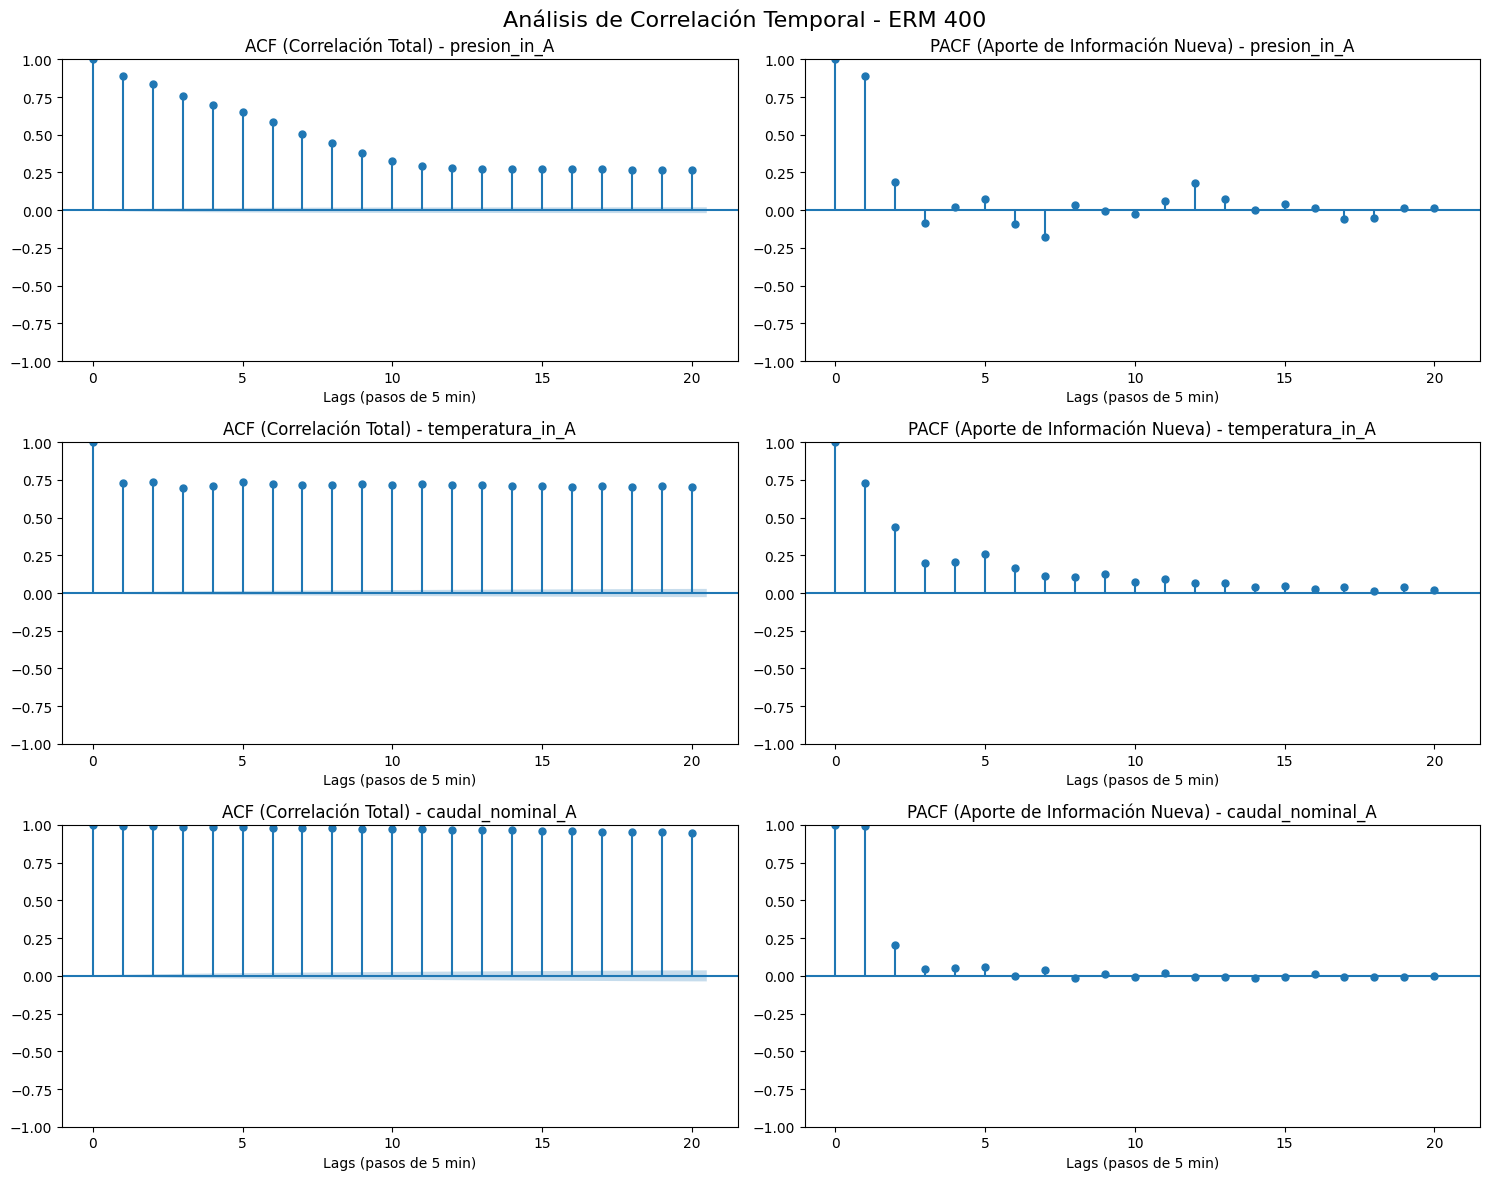

In [11]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# Variables a analizar
variables_fisicas = ['presion_in_A', 'temperatura_in_A', 'caudal_nominal_A']

# Configuración de la figura
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
fig.suptitle('Análisis de Correlación Temporal - ERM 400', fontsize=16)

for i, var in enumerate(variables_fisicas):
    # ACF con bandas de confianza claras
    sm.graphics.tsa.plot_acf(df[var], lags=20, ax=axes[i, 0], 
                             alpha=0.05, title=f'ACF (Correlación Total) - {var}')
    
    # PACF con bandas de confianza claras
    sm.graphics.tsa.plot_pacf(df[var], lags=20, ax=axes[i, 1], 
                              alpha=0.05, title=f'PACF (Aporte de Información Nueva) - {var}', 
                              method='ywm')

    # Añadimos etiquetas para que el lector entienda la zona de ruido
    axes[i, 0].set_xlabel('Lags (pasos de 5 min)')
    axes[i, 1].set_xlabel('Lags (pasos de 5 min)')

plt.tight_layout()
plt.show()

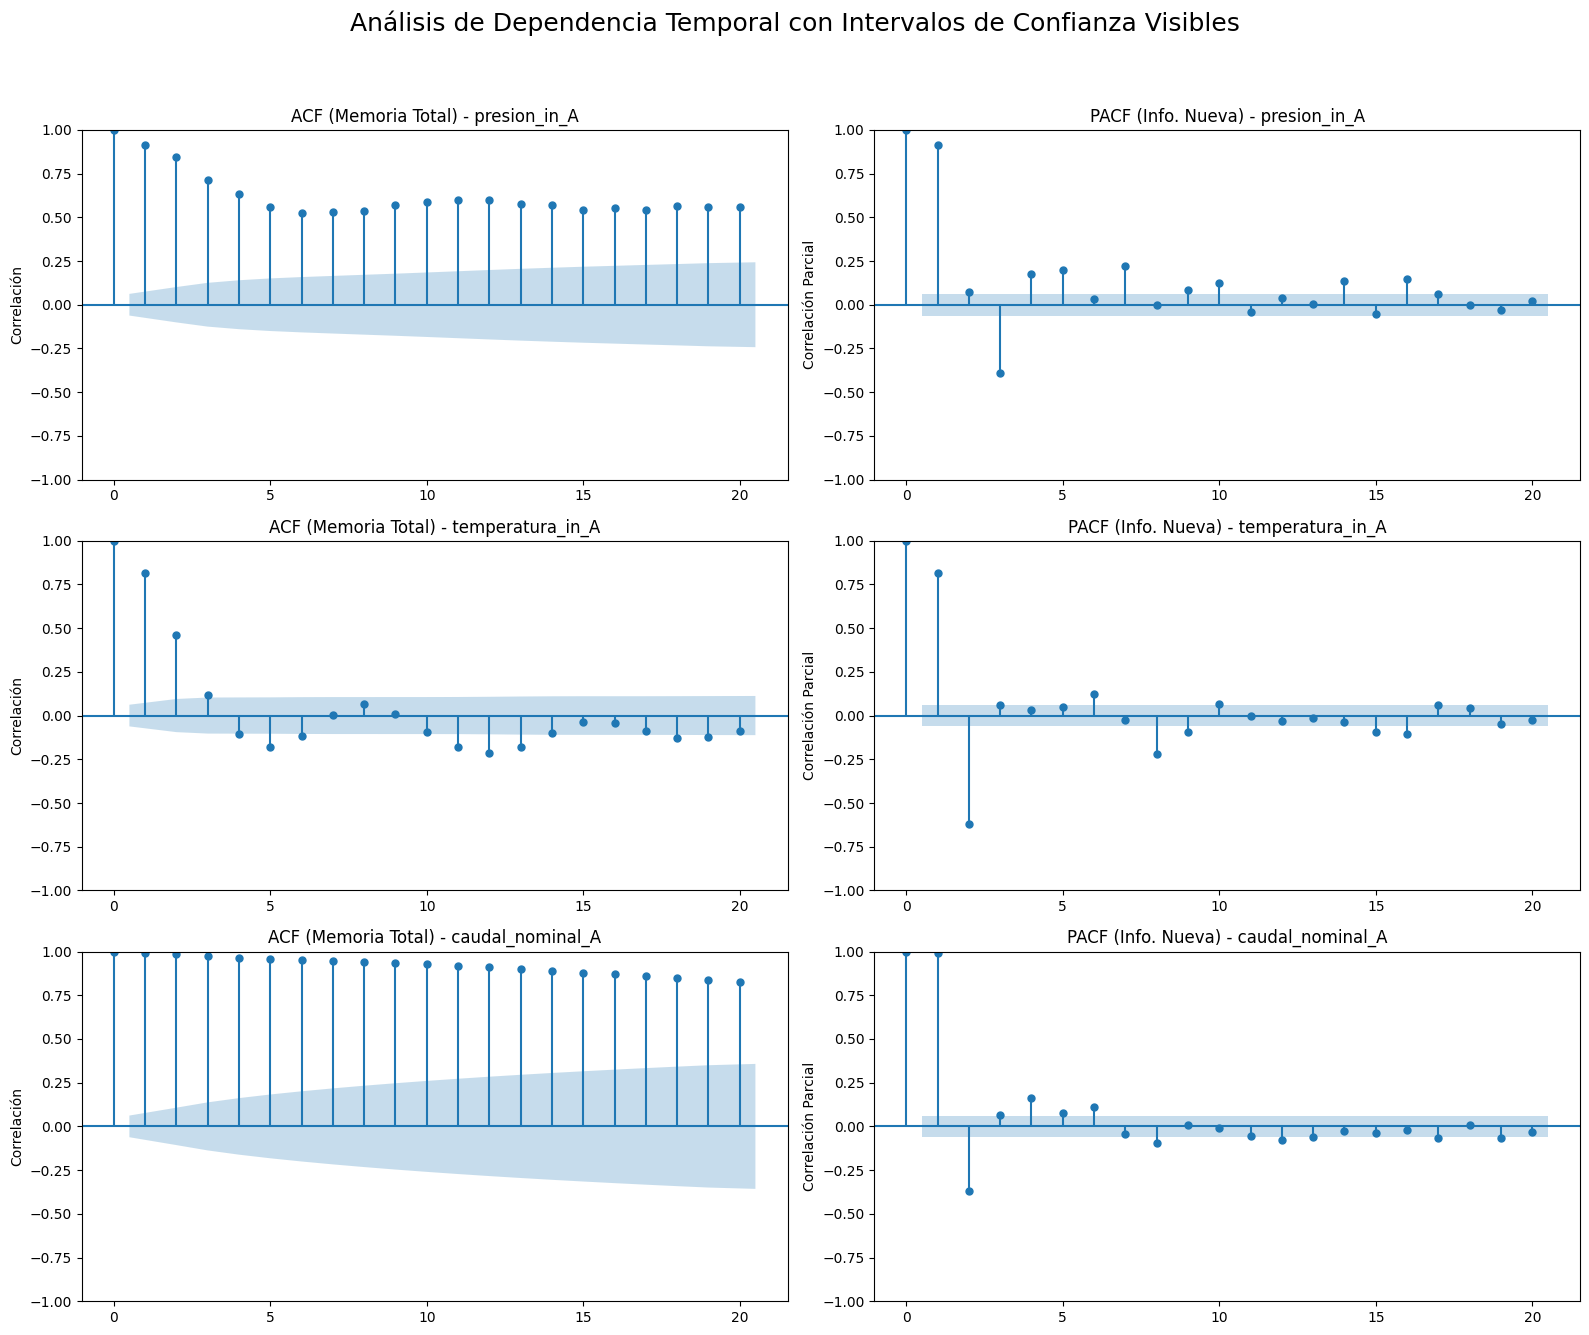

In [5]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Tomamos una muestra para que las bandas sean visibles (ej. 1000 puntos)
# Esto hace que el intervalo de confianza sea ~0.06, perfectamente visible.
df_sample = df.tail(1000) 

variables_fisicas = ['presion_in_A', 'temperatura_in_A', 'caudal_nominal_A']
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 14))

for i, var in enumerate(variables_fisicas):
    # Gráfico ACF
    sm.graphics.tsa.plot_acf(df_sample[var], lags=20, ax=axes[i, 0], 
                             alpha=0.05, # Nivel de confianza 95%
                             title=f'ACF (Memoria Total) - {var}')
    
    # Gráfico PACF
    sm.graphics.tsa.plot_pacf(df_sample[var], lags=20, ax=axes[i, 1], 
                              alpha=0.05, 
                              method='ywm',
                              title=f'PACF (Info. Nueva) - {var}')
    
    # Etiquetas de ejes
    axes[i, 0].set_ylabel('Correlación')
    axes[i, 1].set_ylabel('Correlación Parcial')

plt.suptitle('Análisis de Dependencia Temporal con Intervalos de Confianza Visibles', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 3. CREACIÓN DE LAGS (SLIDING WINDOW)

In [6]:
# 2. CREACIÓN DE LAGS (SLIDING WINDOW) PERSONALIZADOS
# Definimos cuántos lags queremos para cada variable según el PACF
lags_personalizados = {
    'presion_in_A': 5,
    'temperatura_in_A': 3,
    'caudal_nominal_A': 3
}

df_supervisado = df.copy()

for col, n in lags_personalizados.items():
    for i in range(1, n + 1):
        df_supervisado[f'{col}_lag{i}'] = df_supervisado[col].shift(i)

# Eliminamos los nulos creados por el desplazamiento
df_supervisado = df_supervisado.dropna()

print(f"Lags aplicados: {lags_personalizados}")
print(f"Nuevas dimensiones: {df_supervisado.shape}")

Lags aplicados: {'presion_in_A': 5, 'temperatura_in_A': 3, 'caudal_nominal_A': 3}
Nuevas dimensiones: (105104, 25)


In [7]:
df_supervisado.head(3)

,presion_in_A,temperatura_in_A,caudal_bruto_A,caudal_nominal_A,caudal_min_diario_A,caudal_max_diario_A,is_anomaly_sap,tipo_fallo_sap_detalle,anomaly_IF,target_sap_IF,delta_presion_temp,is_scada_anomaly,tipo_fallo_scada,inestabilidad_z,presion_in_A_lag1,presion_in_A_lag2,presion_in_A_lag3,presion_in_A_lag4,presion_in_A_lag5,temperatura_in_A_lag1,temperatura_in_A_lag2,temperatura_in_A_lag3,caudal_nominal_A_lag1,caudal_nominal_A_lag2,caudal_nominal_A_lag3
datetime,,,,,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:25:00,16.765572,11.530180,0.0,0.0,0,64135.745844,0,Normal,0,0,0.025541,1,Pastilla desgastada (Estanqueidad),1.152885,16.740030,16.720991,16.730278,16.760601,16.784145,11.522590,11.533041,11.562312,0.0,0.0,0.0
2023-01-01 00:30:00,16.787861,11.536973,0.0,0.0,0,64135.745844,0,Normal,0,0,0.022289,1,Pastilla desgastada (Estanqueidad),1.125526,16.765572,16.740030,16.720991,16.730278,16.760601,11.530180,11.522590,11.533041,0.0,0.0,0.0
2023-01-01 00:35:00,16.789719,11.523055,0.0,0.0,0,64135.745844,0,Normal,0,0,0.001858,0,Normal / Sin Fallo,1.122532,16.787861,16.765572,16.740030,16.720991,16.730278,11.536973,11.530180,11.522590,0.0,0.0,0.0


## 4. Modelos de ML

In [8]:
# 3. PREPARACIÓN DE VARIABLES PARA RANDOM FOREST 
# Definimos cuáles son nuestras bases físicas
columnas_fisicas = ['presion_in_A', 'temperatura_in_A', 'caudal_nominal_A']

# Recolectamos dinámicamente las columnas originales + los lags recién creados
features = columnas_fisicas + [col for col in df_supervisado.columns if 'lag' in col]
X = df_supervisado[features]

# Definimos el target físico (SCADA)
y = df_supervisado['is_scada_anomaly'] 

# División única para que todos compitan bajo las mismas condiciones
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
X.head(3)

,presion_in_A,temperatura_in_A,caudal_nominal_A,presion_in_A_lag1,presion_in_A_lag2,presion_in_A_lag3,presion_in_A_lag4,presion_in_A_lag5,temperatura_in_A_lag1,temperatura_in_A_lag2,temperatura_in_A_lag3,caudal_nominal_A_lag1,caudal_nominal_A_lag2,caudal_nominal_A_lag3
datetime,,,,,,,,,,,,,,
2023-01-01 00:25:00,16.765572,11.530180,0.0,16.740030,16.720991,16.730278,16.760601,16.784145,11.522590,11.533041,11.562312,0.0,0.0,0.0
2023-01-01 00:30:00,16.787861,11.536973,0.0,16.765572,16.740030,16.720991,16.730278,16.760601,11.530180,11.522590,11.533041,0.0,0.0,0.0
2023-01-01 00:35:00,16.789719,11.523055,0.0,16.787861,16.765572,16.740030,16.720991,16.730278,11.536973,11.530180,11.522590,0.0,0.0,0.0


In [10]:
y.head(3)

datetime
2023-01-01 00:25:00    1
2023-01-01 00:30:00    1
2023-01-01 00:35:00    0
Name: is_scada_anomaly, dtype: int64

## 5. Entrenamiento de Modelos 

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

def entrenar_rf(X_train, X_test, y_train, y_test, titulo):
    """
    Entrena un Random Forest usando los sets ya divididos.
    """
    # Usamos class_weight='balanced' para compensar que hay pocos síntomas vs datos normales
    model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    
    # 2. Configuramos el K-Fold (Stratified es ideal para clases desbalanceadas)
    kfold_validacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # 3. Ejecutamos la Validación Cruzada (¡SOLO en X_train!)
    # Usamos scoring='f1' porque es mejor que accuracy para detectar fallos
    resultados_cv = cross_val_score(model, X_train, y_train, cv=kfold_validacion, scoring='f1')
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n{'='*40}")
    print(f"--- PERFORMANCE: {titulo} ---")
    print(f"{'='*40}")
    
    print(">> 1. VALIDACIÓN CRUZADA K-FOLD (5 Folds) <<")
    print(f"Puntuaciones (F1) de cada fold: {np.round(resultados_cv, 4)}")
    print(f"Promedio F1-Score: {resultados_cv.mean():.4f}\n")
    
    print(">> 2. EVALUACIÓN FINAL EN SET DE TEST (Datos nunca vistos) <<")
    print(classification_report(y_test, y_pred))
    
    return model, y_pred

In [12]:
from xgboost import XGBClassifier

def entrenar_xgboost(X_train, X_test, y_train, y_test):
    # Calculamos el peso para balancear la clase minoritaria
    ratio = (len(y_train) - sum(y_train)) / sum(y_train)
    
    model = XGBClassifier(n_estimators=100, scale_pos_weight=ratio, random_state=42)
    
    # 2. Configuramos el K-Fold (Stratified es ideal para clases desbalanceadas)
    kfold_validacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # 3. Ejecutamos la Validación Cruzada (¡SOLO en X_train!)
    # Usamos scoring='f1' porque es mejor que accuracy para detectar fallos
    resultados_cv = cross_val_score(model, X_train, y_train, cv=kfold_validacion, scoring='f1')

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print("\n--- PERFORMANCE: XGBOOST ---")

    print(">> 1. VALIDACIÓN CRUZADA K-FOLD (5 Folds) <<")
    print(f"Puntuaciones (F1) de cada fold: {np.round(resultados_cv, 4)}")
    print(f"Promedio F1-Score: {resultados_cv.mean():.4f}\n")

    print(">> 2. EVALUACIÓN FINAL EN SET DE TEST (Datos nunca vistos) <<")
    print(classification_report(y_test, y_pred))
    return model, y_pred

In [13]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

def entrenar_svm(X_train, X_test, y_train, y_test):
    # 1. Definimos el modelo lineal rápido
    # 'dual=False' se recomienda cuando el número de muestras es mayor al de variables
    base_svc = LinearSVC(class_weight='balanced', random_state=42, max_iter=5000, dual=False)
    
    # 2. Configuramos el K-Fold (Stratified es ideal para clases desbalanceadas)
    kfold_validacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # 3. Ejecutamos la Validación Cruzada (¡SOLO en X_train!)
    # Usamos scoring='f1' porque es mejor que accuracy para detectar fallos
    resultados_cv = cross_val_score(base_svc, X_train, y_train, cv=kfold_validacion, scoring='f1')

    # Calibración y Entrenamiento Final
    # Lo envolvemos para obtener probabilidades (predict_proba)
    model = CalibratedClassifierCV(base_svc)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print("\n--- PERFORMANCE: LINEAR SVM (Optimizado) ---")
    
    print(">> 1. VALIDACIÓN CRUZADA K-FOLD (5 Folds) <<")
    print(f"Puntuaciones (F1) de cada fold: {np.round(resultados_cv, 4)}")
    print(f"Promedio F1-Score: {resultados_cv.mean():.4f}\n")

    print(">> 2. EVALUACIÓN FINAL EN SET DE TEST (Datos nunca vistos) <<")
    print(classification_report(y_test, y_pred))
    return model, y_pred

In [14]:
from sklearn.neural_network import MLPClassifier

def entrenar_mlp_nn(X_train, X_test, y_train, y_test):
    # Arquitectura de 2 capas ocultas
    model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', 
                          max_iter=500, random_state=42)
    
    # 2. Configuramos el K-Fold (Stratified es ideal para clases desbalanceadas)
    kfold_validacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # 3. Ejecutamos la Validación Cruzada (¡SOLO en X_train!)
    # Usamos scoring='f1' porque es mejor que accuracy para detectar fallos
    resultados_cv = cross_val_score(model, X_train, y_train, cv=kfold_validacion, scoring='f1')
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print("\n--- PERFORMANCE: MULTI-LAYER PERCEPTRON (NN) ---")
    
    print(">> 1. VALIDACIÓN CRUZADA K-FOLD (5 Folds) <<")
    print(f"Puntuaciones (F1) de cada fold: {np.round(resultados_cv, 4)}")
    print(f"Promedio F1-Score: {resultados_cv.mean():.4f}\n")

    print(">> 2. EVALUACIÓN FINAL EN SET DE TEST (Datos nunca vistos) <<")
    print(classification_report(y_test, y_pred))
    return model, y_pred

**PARTE 1: Comparativa SAP vs. SCADA**

Aquí usamos el mismo modelo (Random Forest) para exponer la diferencia de calidad entre los datos de gestión y los físicos.

In [15]:
df_supervisado.columns

Index(['presion_in_A', 'temperatura_in_A', 'caudal_bruto_A',
       'caudal_nominal_A', 'caudal_min_diario_A', 'caudal_max_diario_A',
       'is_anomaly_sap', 'tipo_fallo_sap_detalle', 'anomaly_IF',
       'target_sap_IF', 'delta_presion_temp', 'is_scada_anomaly',
       'tipo_fallo_scada', 'inestabilidad_z', 'presion_in_A_lag1',
       'presion_in_A_lag2', 'presion_in_A_lag3', 'presion_in_A_lag4',
       'presion_in_A_lag5', 'temperatura_in_A_lag1', 'temperatura_in_A_lag2',
       'temperatura_in_A_lag3', 'caudal_nominal_A_lag1',
       'caudal_nominal_A_lag2', 'caudal_nominal_A_lag3'],
      dtype='str')


--- PERFORMANCE: SÍNTOMAS SAP (Gestión) ---
>> 1. VALIDACIÓN CRUZADA K-FOLD (5 Folds) <<
Puntuaciones (F1) de cada fold: [0.2609 0.3815 0.3158 0.3584 0.2771]
Promedio F1-Score: 0.3187

>> 2. EVALUACIÓN FINAL EN SET DE TEST (Datos nunca vistos) <<
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     20848
           1       0.96      0.28      0.43       173

    accuracy                           0.99     21021
   macro avg       0.98      0.64      0.71     21021
weighted avg       0.99      0.99      0.99     21021


--- PERFORMANCE: SÍNTOMAS SCADA (Física) ---
>> 1. VALIDACIÓN CRUZADA K-FOLD (5 Folds) <<
Puntuaciones (F1) de cada fold: [0.5965 0.588  0.6204 0.5947 0.5995]
Promedio F1-Score: 0.5998

>> 2. EVALUACIÓN FINAL EN SET DE TEST (Datos nunca vistos) <<
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     19390
           1       0.80      0.50      0.62      1631

    accuracy

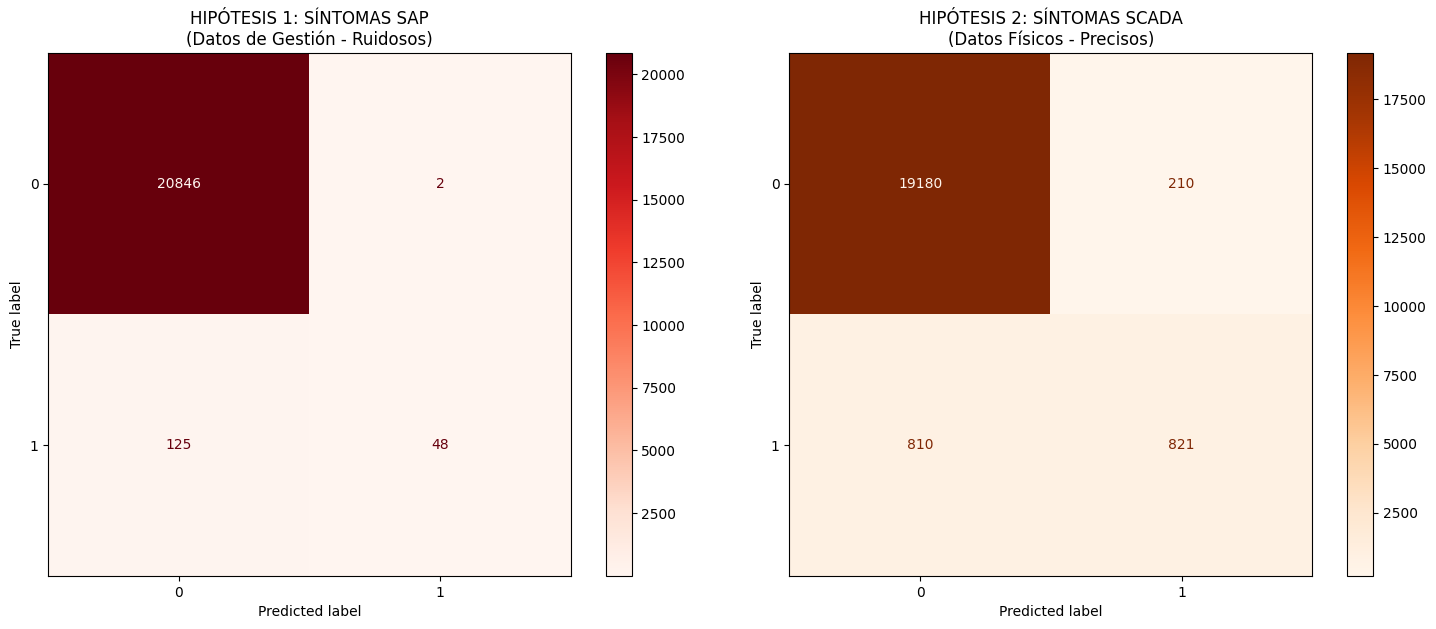

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

# --- A. Entrenar para SAP ---
y_sap = df_supervisado['is_anomaly_sap']
X_train_sap, X_test_sap, y_train_sap, y_test_sap = train_test_split(X, y_sap, test_size=0.2, random_state=42, stratify=y_sap)
model_sap, pred_sap = entrenar_rf(X_train_sap, X_test_sap, y_train_sap, y_test_sap, "SÍNTOMAS SAP (Gestión)")

# --- B. Entrenar para SCADA ---
y_scada = df_supervisado['is_scada_anomaly']
X_train_scada, X_test_scada, y_train_scada, y_test_scada = train_test_split(X, y_scada, test_size=0.2, random_state=42, stratify=y_scada)
model_scada, pred_scada = entrenar_rf(X_train_scada, X_test_scada, y_train_scada, y_test_scada, "SÍNTOMAS SCADA (Física)")

# --- C. Visualización Comparativa de Hipótesis ---
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ConfusionMatrixDisplay.from_predictions(y_test_sap, pred_sap, ax=ax[0], cmap='Reds')
ax[0].set_title('HIPÓTESIS 1: SÍNTOMAS SAP\n(Datos de Gestión - Ruidosos)')

ConfusionMatrixDisplay.from_predictions(y_test_scada, pred_scada, ax=ax[1], cmap='Oranges')
ax[1].set_title('HIPÓTESIS 2: SÍNTOMAS SCADA\n(Datos Físicos - Precisos)')

plt.tight_layout()
plt.show()

**PARTE 2: Competencia de Modelos (Selección de la Herramienta)**

Ahora que los resultados de arriba te dirán que "SCADA es el camino", procedes a optimizar la detección física con los otros modelos que creamos.

In [12]:
# Trabajamos sobre los datos de SCADA (los mejores)
# X_train_scada, X_test_scada, etc. ya están definidos arriba
print("\n" + "="*50)
print("INICIO DE COMPETENCIA DE MODELOS (TARGET: SCADA)")
print("="*50)
# Ejecutar modelos
model_rf, pred_rf = entrenar_rf(X_train_scada, X_test_scada, y_train_scada, y_test_scada, "RANDOM FOREST" )
model_xgb, pred_xgb = entrenar_xgboost(X_train_scada, X_test_scada, y_train_scada, y_test_scada)
model_svm, pred_svm = entrenar_svm(X_train_scada, X_test_scada, y_train_scada, y_test_scada)
model_nn, pred_nn = entrenar_mlp_nn(X_train_scada, X_test_scada, y_train_scada, y_test_scada)


INICIO DE COMPETENCIA DE MODELOS (TARGET: SCADA)

--- PERFORMANCE: RANDOM FOREST ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19390
           1       1.00      1.00      1.00      1631

    accuracy                           1.00     21021
   macro avg       1.00      1.00      1.00     21021
weighted avg       1.00      1.00      1.00     21021


--- PERFORMANCE: XGBOOST ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19390
           1       0.99      1.00      0.99      1631

    accuracy                           1.00     21021
   macro avg       0.99      1.00      1.00     21021
weighted avg       1.00      1.00      1.00     21021


--- PERFORMANCE: LINEAR SVM (Optimizado) ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     19390
           1       0.85      0.73      0.78      1631

    accuracy        

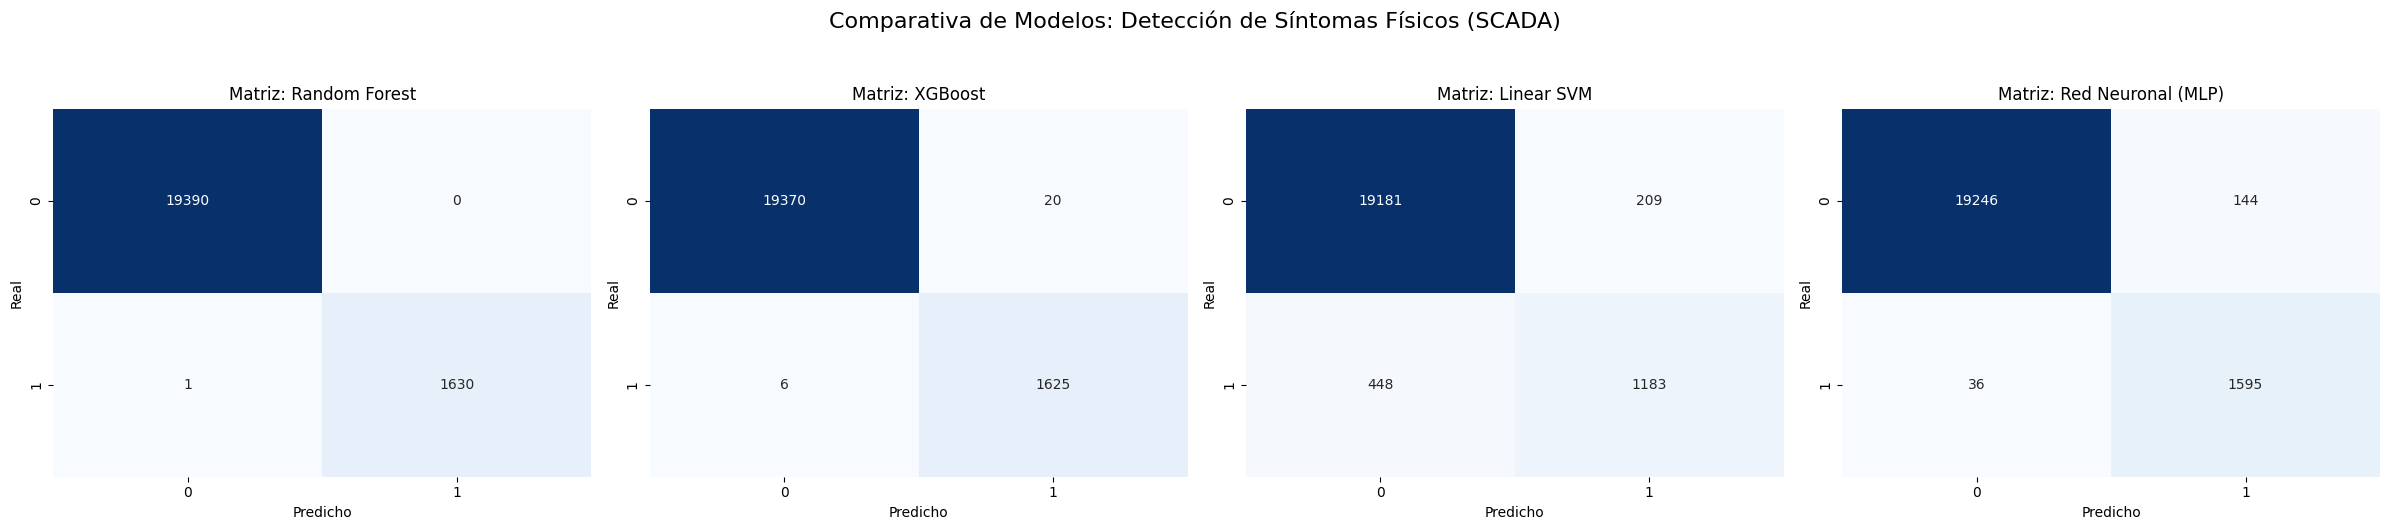

In [ ]:
# --- Visualización de la Competencia ---
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. Definición de la Función
def plot_confusion_en_eje(y_real, y_pred, titulo, ax_obj):
    """
    Dibuja la matriz de confusión en un eje específico del subplot.
    """
    cm = confusion_matrix(y_real, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_obj, cbar=False)
    ax_obj.set_title(f'Matriz: {titulo}')
    ax_obj.set_ylabel('Real')
    ax_obj.set_xlabel('Predicho')

# 2. Visualización de la Competencia
# --- Visualización de la Competencia (Target: SCADA) ---
fig, ax = plt.subplots(2, 2, figsize=(24, 5)) # Cambiado a 4 columnas

plot_confusion_en_eje(y_test_scada, pred_rf, "Random Forest", ax[0])
plot_confusion_en_eje(y_test_scada, pred_xgb, "XGBoost", ax[1])
plot_confusion_en_eje(y_test_scada, pred_svm, "Linear SVM", ax[2])
plot_confusion_en_eje(y_test_scada, pred_nn, "Red Neuronal (MLP)", ax[3])

plt.suptitle('Comparativa de Modelos: Detección de Síntomas Físicos (SCADA)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()